# Test of origin of replication deconvolution with fixed offset configs

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [51]:
def deconvolve_and_plot_model(origin_sweep, config_mode, title, selected_origins,
                             gamma=0.04, kappa=1, impute_50=True, copy_correct=True):
    """
    Create a single plot for a model with multiple origins as rows
    """    
    # Create a figure with 4 rows (one for each origin) and 3 columns 
    # (replicates 1, 2, combined)
    fig, axes = plt.subplots(len(selected_origins), 5, 
                             figsize=(16, 3 * len(selected_origins)))
    
    # Process each origin
    for row, oridb in enumerate(selected_origins):
                
        # Analyze the origin
        footprint = origin_sweep.analyze_origin(oridb, impute_50_rep2=impute_50,
                                               copy_correct=copy_correct)

        # ------------- Raw data ----------------------------------
        from src.helpers import plot_raw_timepoints
        footprint_means = origin_sweep.footprint.mean((1, 2))

        tp1 = origin_sweep.config1.timepoints
        tp2 = origin_sweep.config2.timepoints

        plt.sca(axes[row][0])
        plt.plot(tp1, footprint_means[:len(tp1)], label='WT1')
        plot_raw_timepoints(origin_sweep.config1)
        plt.title("Replicate 1")
        plt.ylim(0, 2.5)
        plt.ylabel(f"Origin {oridb}", fontsize=12)
        if row < len(selected_origins)-1: plt.xticks([])

        plt.sca(axes[row][1])
        plt.plot(tp2, footprint_means[len(tp1):], label="WT2")
        plot_raw_timepoints(origin_sweep.config2)
        plt.title("Replicate 2")
        plt.ylim(0, 2.5)
        plt.yticks([])
        if row < len(selected_origins)-1: plt.xticks([])
                
        # ------------------------------------------------------------
            
        # For each replicate type (1, 2, combined)
        for col, replicate in enumerate([1, 2, 'combined']):

            # Set the current subplot
            plt.sca(axes[row][col+2])                
            plt.yticks([])

            if row < len(selected_origins)-1: plt.xticks([])
            
            # Set up and perform deconvolution
            origin_sweep.setup_footprint_deconvolution(replicate=replicate, 
                copy_correct=copy_correct)
            origin_sweep.deconvolve_footprint(gamma=gamma, kappa=kappa)
            
            # Plot the results
            origin_sweep.plot_deconvolved_footprint(fig=fig)
            
            # Set y-axis limits
            plt.ylim(0, 2.5)
    
    # Add overall title
    plt.suptitle(title, y=1.015, fontweight='demi', fontsize=16)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save figure
    from src.figure_configs import save_figure_for_paper
    save_figure_for_paper(f'output/origins_model_comparison/{title.replace(":", "_")}.png')
    
    return fig


In [42]:
# # origin_sweep.print_efficient_origins()
# selected_origins = [
# #    'oridb_10', # ARS107 
# #    'oridb_295', # ARS718
#    'oridb_289',
# #    'oridb_193', # late
# #    'oridb_558', # late
#     'oridb_498', # ARS1120, late
# ]

# origin_sweep.print_efficient_origins()
selected_origins = [
   'oridb_10', # ARS107 
   'oridb_295', # ARS718
   'oridb_289',
   'oridb_193',
   'oridb_558',
   'oridb_498', # ARS1120
]

Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr,

Completed - 00:00:20.998
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
0/165 - 00:00:00.146
Completed - 00:00:23.062
Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsamp

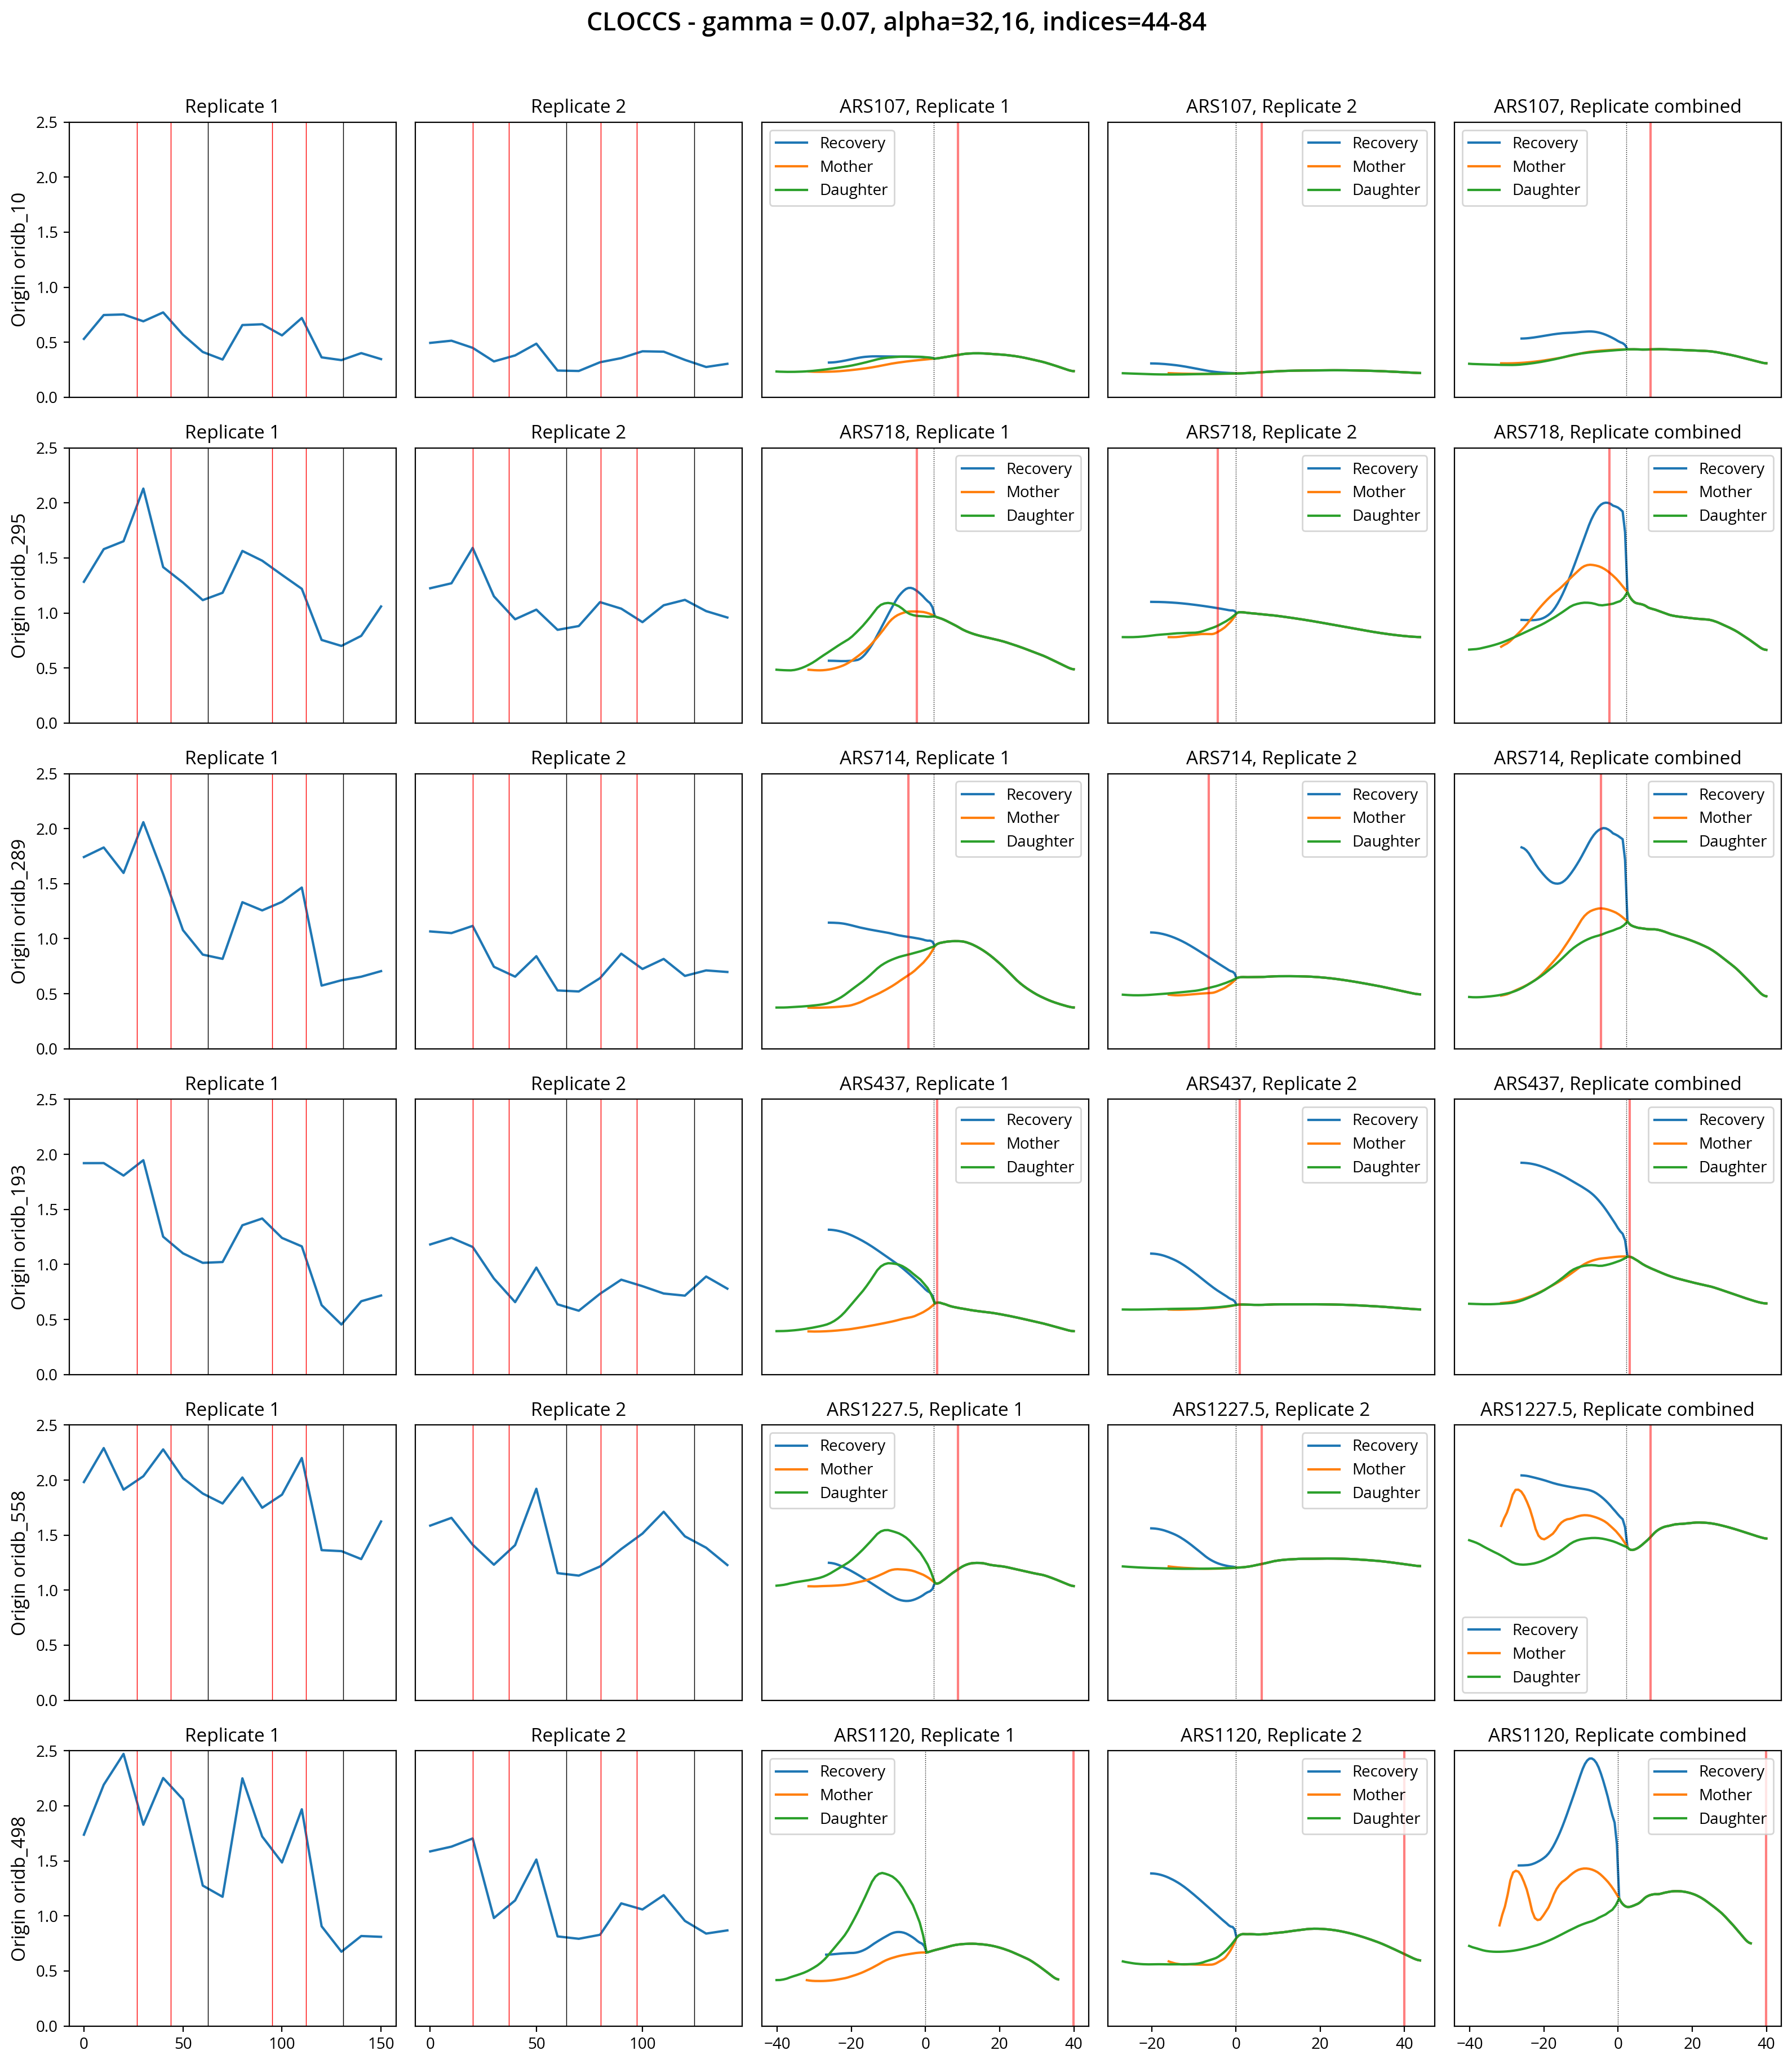

In [52]:
from pipeline.origin_alpha_sweep import OriginAlphaSweep
import matplotlib.pyplot as plt

# Initialize the sweep object
origin_sweep = OriginAlphaSweep('output/draft3_run/')

impute_50s = [False]##], True]
titles = [
    'CLOCCS - gamma = 0.07, alpha=32,16, indices=44-84',
]

fig = deconvolve_and_plot_model(
    origin_sweep,
    config_mode='cloccs',
    impute_50=False,
    title=titles[0],
    selected_origins=selected_origins,
    gamma=0.1,
    kappa=0.001,
    copy_correct=False)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr,

Completed - 00:00:21.207
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
0/165 - 00:00:00.146
Completed - 00:00:23.127
Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsamp

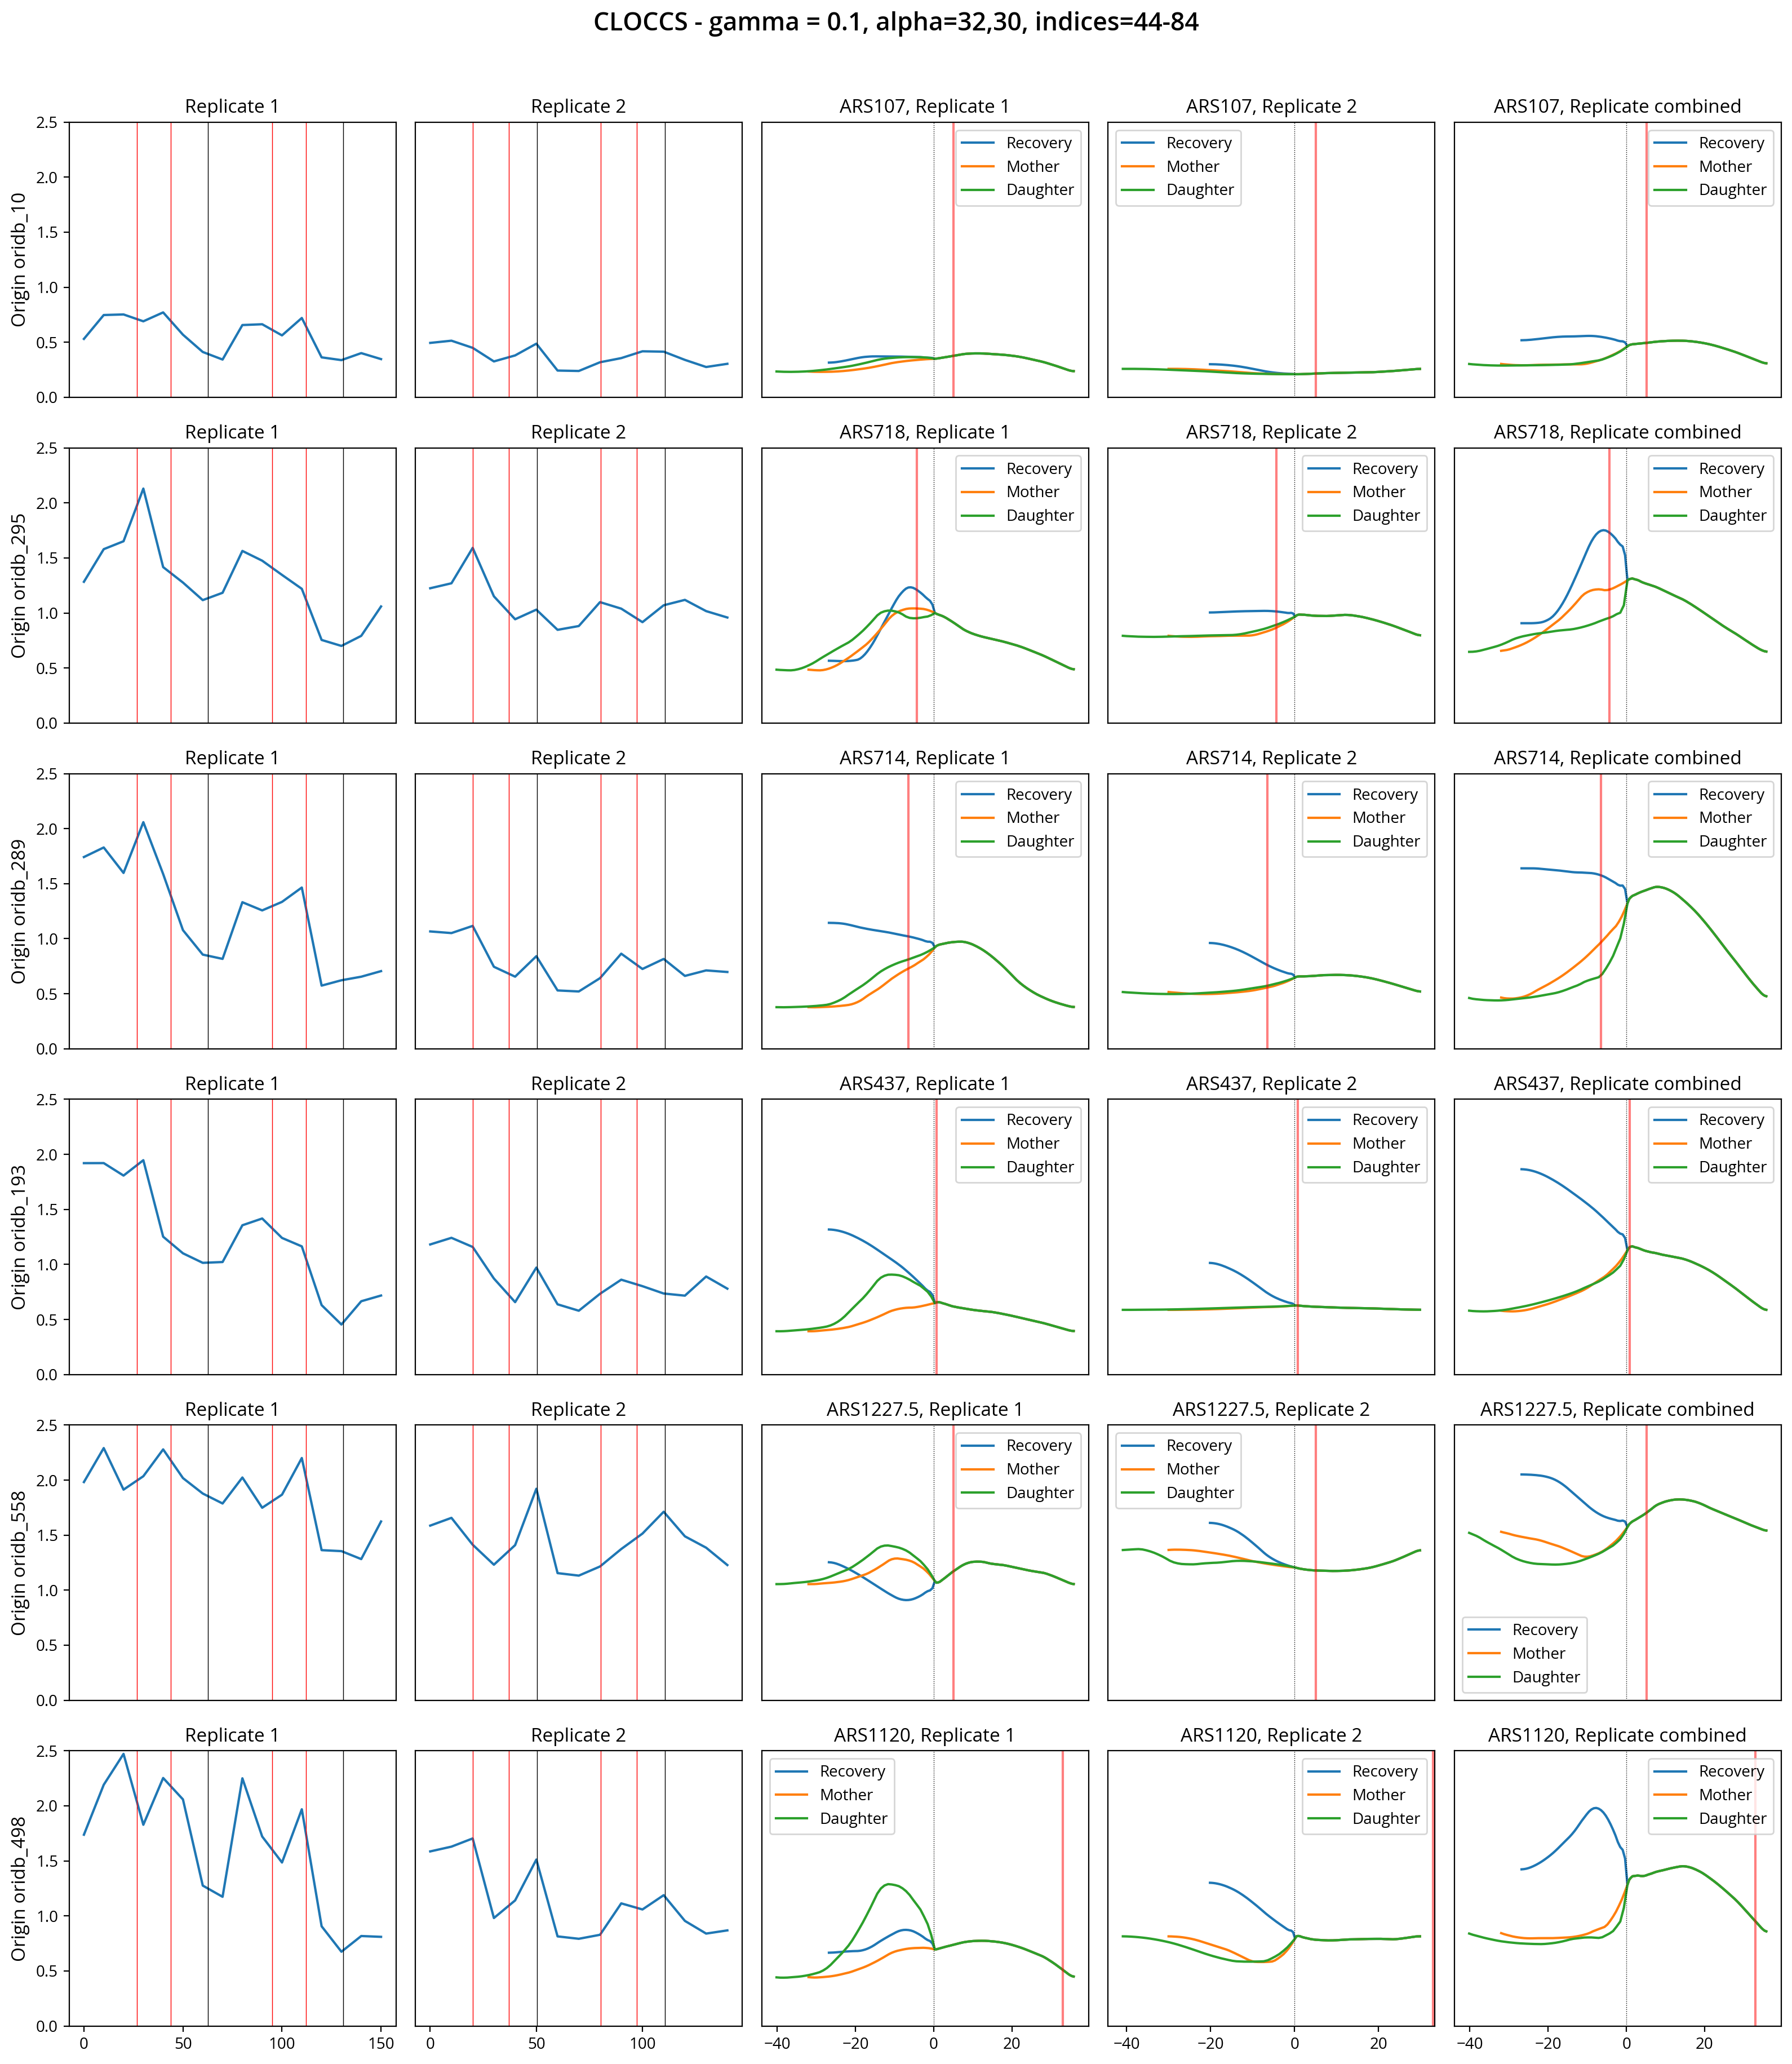

In [61]:
from pipeline.origin_alpha_sweep import OriginAlphaSweep
import matplotlib.pyplot as plt

# Initialize the sweep object
origin_sweep = OriginAlphaSweep('output/draft3_run/')

impute_50s = [False]##], True]
titles = [
    f'CLOCCS - gamma = 0.1, alpha={origin_sweep.config1.alpha},{origin_sweep.config2.alpha}, indices=44-84',
]

fig = deconvolve_and_plot_model(
    origin_sweep,
    config_mode='cloccs',
    impute_50=False,
    title=titles[0],
    selected_origins=selected_origins,
    gamma=0.1,
    kappa=0.01,
    copy_correct=False)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Loading copy correction N, Fr,

Completed - 00:00:23.928
Loading copy correction N, Fr, B from output/draft3_run/
todo: Loading prototype replication data from: output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
0/165 - 00:00:00.158
Completed - 00:00:24.475
Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 11
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsamp

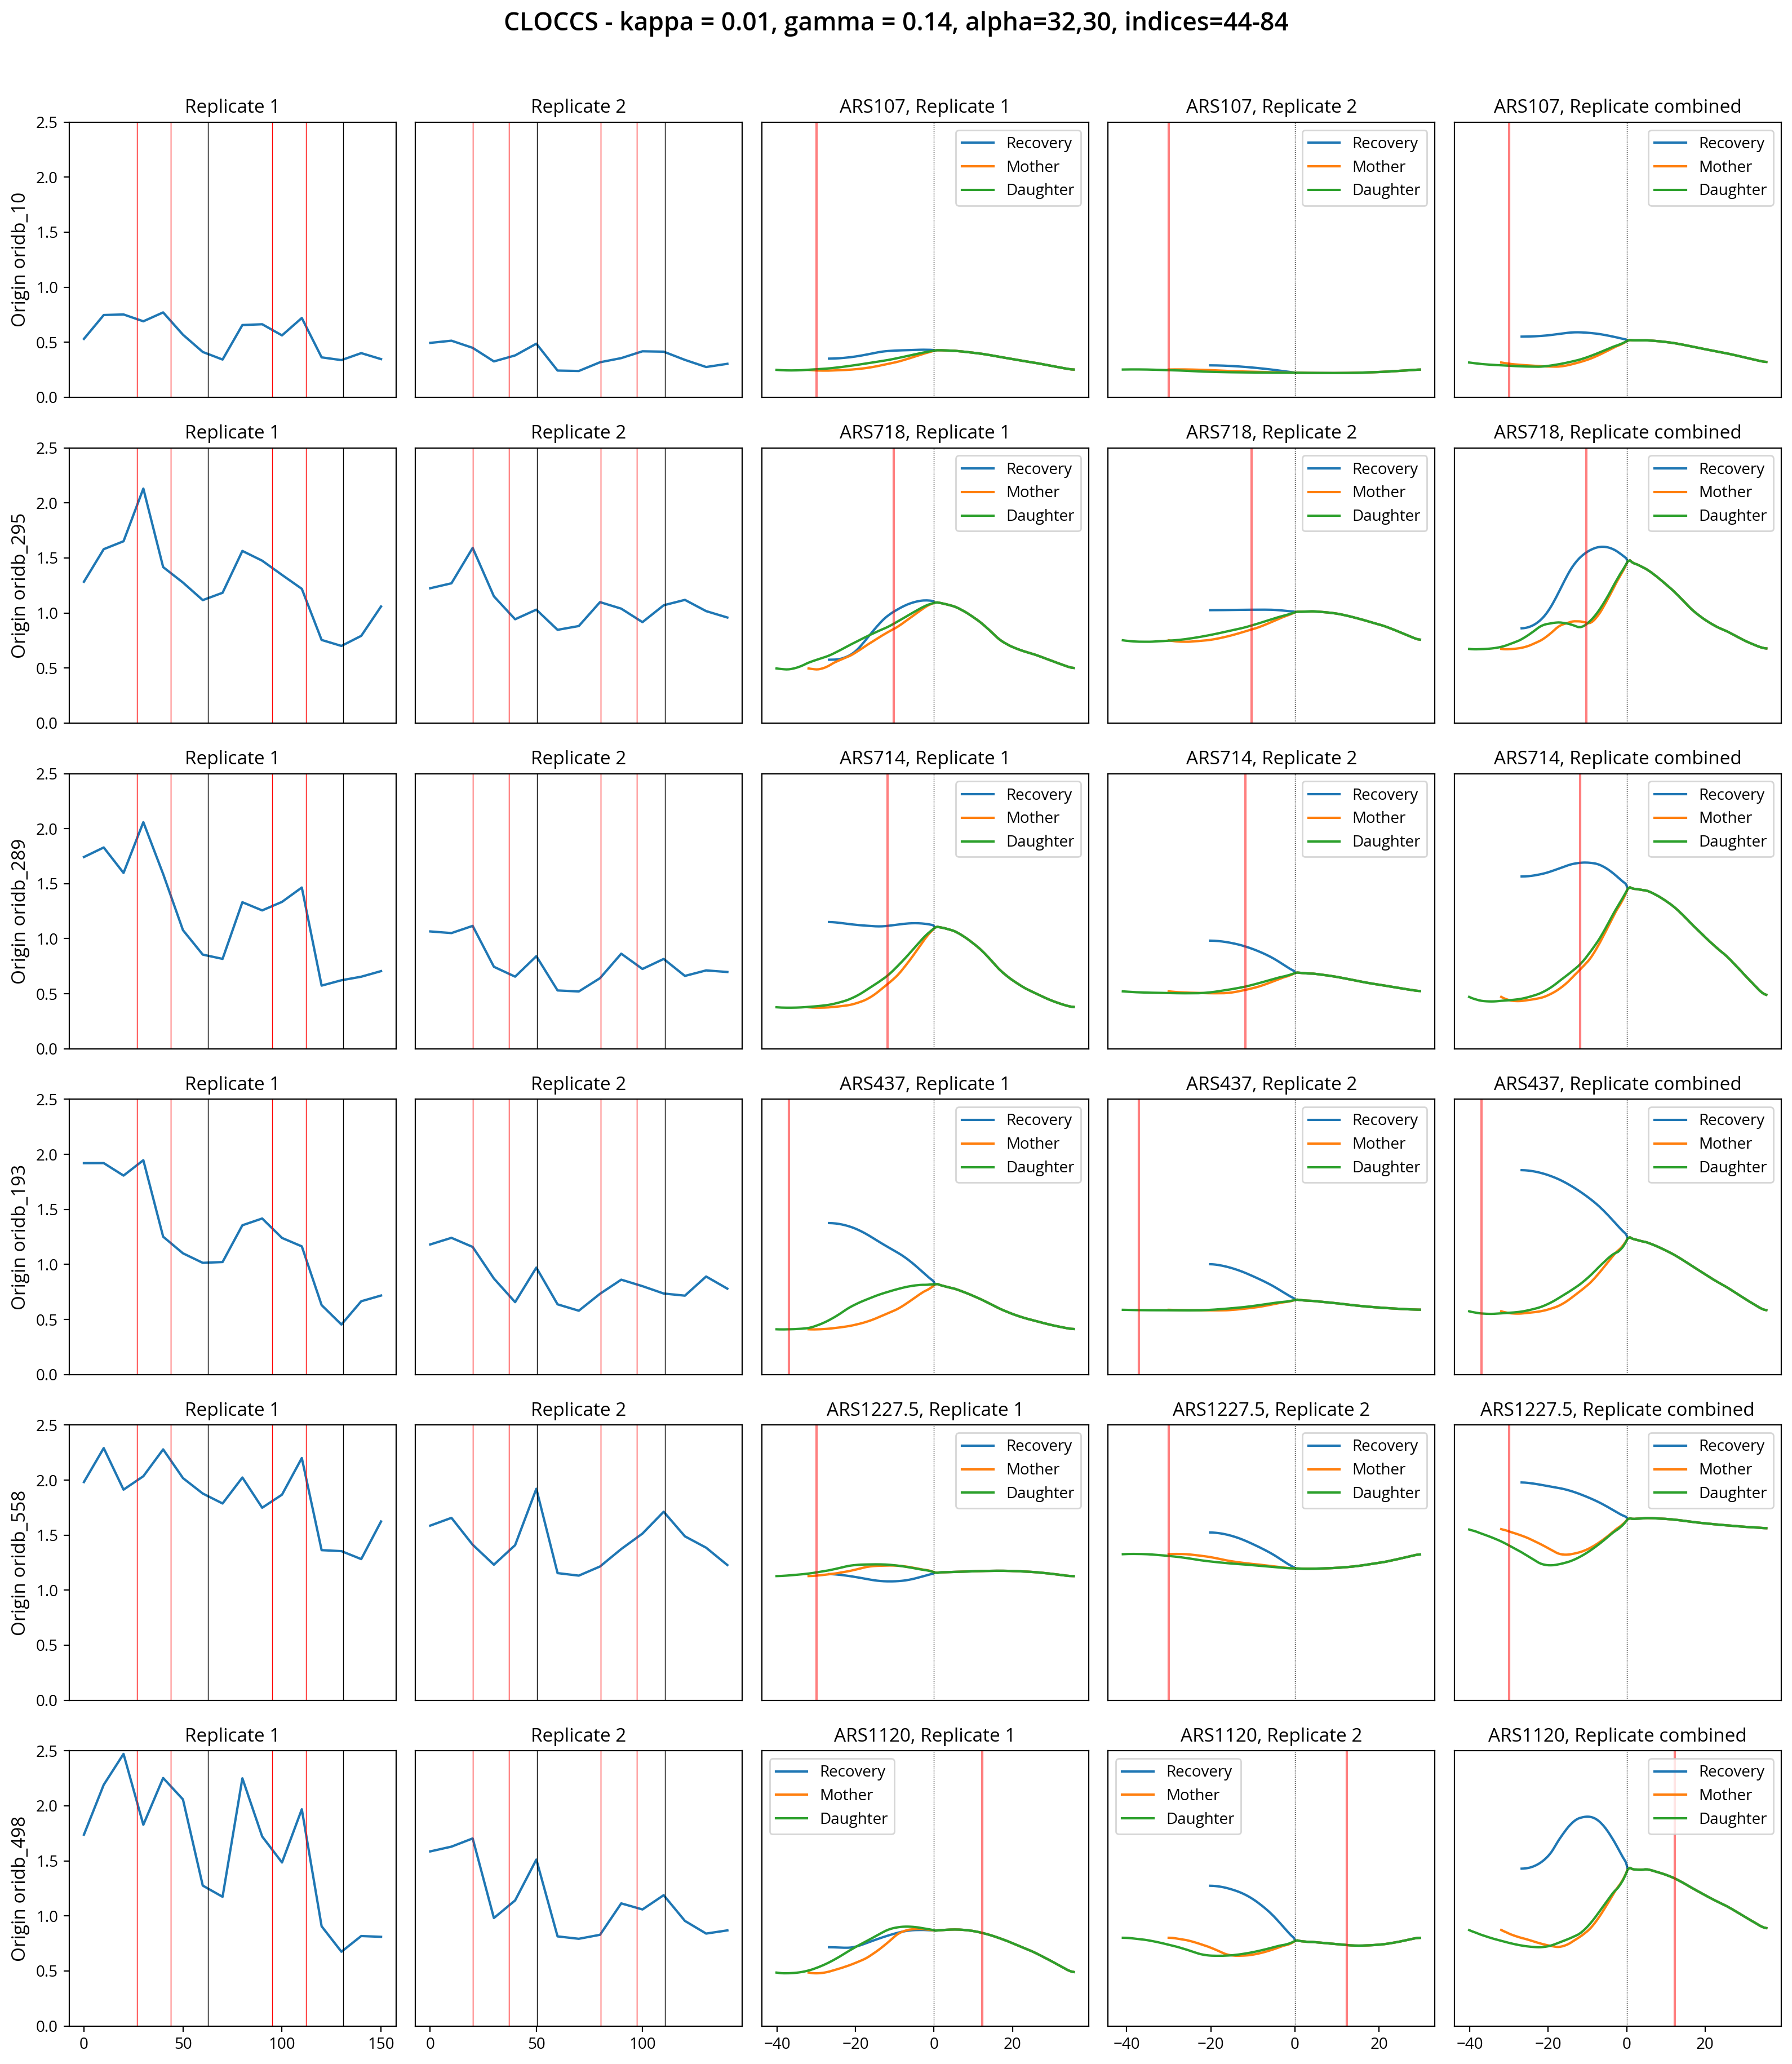

In [64]:

# Initialize the sweep object
origin_sweep = OriginAlphaSweep('output/draft3_run/')

gamma = 0.14
kappa = 0.01
impute_50s = [False]##], True]
titles = [
    f'CLOCCS - kappa = {kappa}, gamma = {gamma}, '
    f'alpha={origin_sweep.config1.alpha},{origin_sweep.config2.alpha}, indices=44-84',
]

fig = deconvolve_and_plot_model(
    origin_sweep,
    config_mode='cloccs',
    impute_50=False,
    title=titles[0],
    selected_origins=selected_origins,
    gamma=gamma,
    kappa=kappa,
    copy_correct=False)
